## Common imports

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from src.barbara_functions_for_notebooks_1_2_3_4_5 import load_autoimmune_data, get_duplicate_patient_ids, get_duplicate_values, check_duplicate_protein_ids, transpose_autoimmune_data, split_bl_m6, harmonisation_validator, export_to_csv, run_pca_visualisation, run_umap_visualisation, plot_heatmap
from src.barbara_functions_for_notebooks_1_2_3_4_5 import select_top_variance_features, map_selected_features_to_genes

## Define directory and file paths

In [2]:
PROJECT_ROOT = Path.cwd().parents[1]
DATA_DIR = PROJECT_ROOT / "datasets"
INITIAL_AUTOIMMUNE_ANNOTATION_TABLE = "0_Initial_Autoimmune_Annotation_Table.csv"
INITIAL_AUTOIMMUNE_FILE = "1_Initial_Autoimmune.xlsx"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY = "2_Initial_Autoimmune_RA_Only.csv"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED = "3_Initial_Autoimmune_RA_Only_Transposed.csv"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED_BL = "4_Initial_Autoimmune_RA_Only_Transposed_BL.csv"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED_M6 = "5_Initial_Autoimmune_RA_Only_Transposed_M6.csv"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED_BL_LOG = "6_Initial_Autoimmune_RA_Only_Transposed_BL_Log.csv"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED_BL_LOG_STANDARDISED = "7_Initial_Autoimmune_RA_Only_Transposed_BL_Log_Standardised.csv"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED_BL_LOG_TOP50VARIANCE ="8_Initial_Autoimmune_RA_Only_Transposed_BL_Log_Top50Variance.csv"
from pathlib import Path

print(Path.cwd())
print(Path(DATA_DIR))
print(Path(DATA_DIR) / INITIAL_AUTOIMMUNE_FILE)
print(Path(DATA_DIR) / INITIAL_AUTOIMMUNE_FILE_RA_ONLY)
print(Path(DATA_DIR) / INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED)

C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\notebooks\selection
C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets
C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets\1_Initial_Autoimmune.xlsx
C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets\2_Initial_Autoimmune_RA_Only.csv
C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets\3_Initial_Autoimmune_RA_Only_Transposed.csv


## Features selection based on variance - select the top 50 most variable proteins in the dataset

In [18]:
bl_dataset_most_variant = pd.read_csv(DATA_DIR / INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED_BL_LOG)

bl_top50, variance_scores = select_top_variance_features(bl_dataset_most_variant, top_n=50)

print(bl_top50.shape)
print(variance_scores.head(50))

(265, 50)
1066836537c_CPSF6           4.177377
1043143555c_APOE            3.131626
0104743520c_EIF4H           2.948054
0104745245c_TNC             2.889468
1043171268c_HNRNPA1         2.884419
1047909961c_MCM2            2.785862
0104745679c_SPP1            2.785380
0104745733c_VIM             2.611864
1043171373c_FGB             2.597983
1043138774c_MBP             2.514994
0105507292c_NONO            2.502956
1066863255c_IGFBP6          2.474865
1047911146c_PDIA6           2.461945
1043143555_APOE             2.400579
0105483201c_NPM1            2.180735
0105510087c_SFPQ            2.163544
1047912089_BTBD7            2.081385
1066838183_CHD4             2.078858
1047887413c_LMNB1           2.018243
0104745249c_IGF1            1.973747
1043142674_FBXO44           1.950915
ZNF574_1066529052_ZNF574    1.950336
0104742995c_ACTB            1.932506
0105511133c_DNAJB1          1.903111
0105483601c_CLU             1.897632
0104743232c_PTBP1           1.828215
0105482048c_ENO1            

## Visualise the top 50 most variable proteins

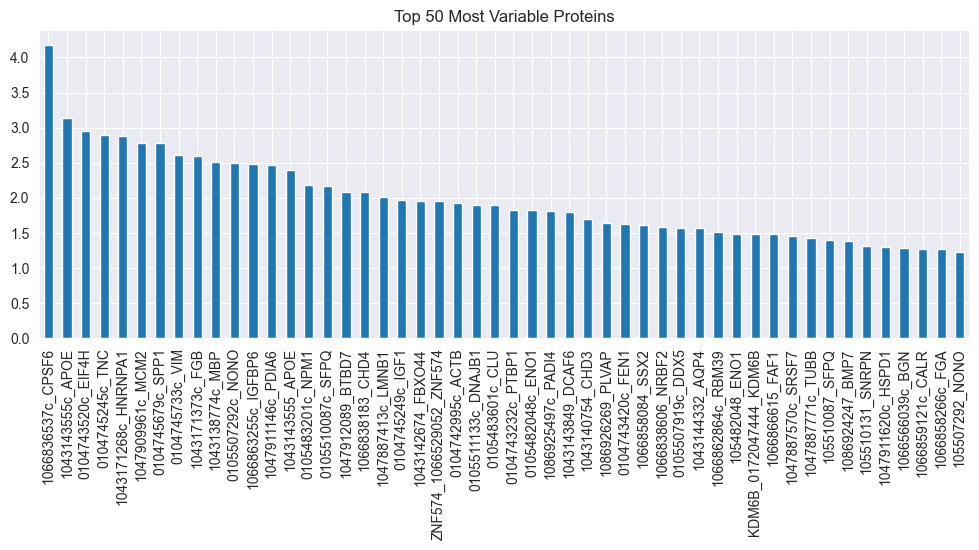

In [19]:
variance_scores.head(50).plot(kind="bar", figsize=(12,4))
plt.title("Top 50 Most Variable Proteins")
plt.show()

## Save the top 50 most variable proteins to a .csv file for use in downstream analyses

In [5]:
bl_top50.to_csv(DATA_DIR / "8_Initial_Autoimmune_RA_Only_Transposed_BL_Log_Top50Variance.csv",index=True)

## Map the selected top 50 to the gene names (description) in the annotation table for better interpretability

In [17]:
annotation_df = pd.read_csv(DATA_DIR / INITIAL_AUTOIMMUNE_ANNOTATION_TABLE)

variance_df = pd.read_csv(DATA_DIR / INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED_BL_LOG_TOP50VARIANCE)

variance_named_df, mapping_dict = map_selected_features_to_genes(variance_df,annotation_df)

pd.DataFrame({
    "Original": variance_df.columns,
    "Mapped": variance_named_df.columns
}).head(51)


,Original,Mapped
0,Unnamed: 0,Unnamed: 0
1,1066836537c_CPSF6,cleavage and polyadenylation specific factor 6...
2,1043143555c_APOE,apolipoprotein E
3,0104743520c_EIF4H,eukaryotic translation initiation factor 4H
4,0104745245c_TNC,tenascin C
5,1043171268c_HNRNPA1,heterogeneous nuclear ribonucleoprotein A1
6,1047909961c_MCM2,minichromosome maintenance complex component 2
7,0104745679c_SPP1,secreted phosphoprotein 1
8,0104745733c_VIM,vimentin
9,1043171373c_FGB,fibrinogen beta chain
